# Book - Modern Time Series Forecasting with Python

## Chapter 01 - Introduction to Time Series Data and Analysis

### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* seaborn: 0.13.2
* statsmodels: 0.14.1

#### Loading libries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import lag_plot

import warnings
warnings.filterwarnings('ignore')

#### Below code block demonstrate how to make an easy time series Series in Pandas

In [2]:
# Create a date range for the year 2024
dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='D')

# Generate some random data
data = np.random.randn(len(dates))

# Create a time series Series
ts = pd.Series(data, index=dates)

ts = ts.round(4)


print(ts.head())


2024-01-01    0.8045
2024-01-02   -0.1345
2024-01-03    2.3699
2024-01-04   -0.0880
2024-01-05   -0.1230
Freq: D, dtype: float64


#### Below code block demonstrate how to loading time series data

In [3]:
# Assuming your CSV has a 'Date' column and a 'Value' column
# And 'Date' column contains dates in 'YYYY-MM-DD' format
# If not, you can use the 'format' argument to specify the format


# Load your data
data = pd.read_csv('time_series_data.csv', index_col='Date', parse_dates=['Date'])


print(data.head())


            Value
Date             
2025-01-01     10
2025-01-02      6
2025-01-03     10
2025-01-04      6
2025-01-05      5


#### In Pandas, the key advantages of using a DatetimeIndex is the ability to perform intuitive time-based indexing and slicing. Bellow code demonstrates

In [4]:
# Select data for a specific date
print(" \n ======   data for a specific date       ====== \n ")
print(ts['2024-06-15'])


# Select data for a date range
print(" \n ======    data for a date range      ====== \n ")
print(ts['2024-03-01':'2024-03-31'])

# Select data for a specific month
print(" \n ======     data for a specific month     ====== \n ")
print(ts['2024-09'])

# Select data for a specific year
print("\n  ======     data for a specific year    ====== \n ")
print(ts['2024'])


 
 ======   data for a specific date       ====== 
 
-0.5701
 
 ======    data for a date range      ====== 
 
2024-03-01   -0.1842
2024-03-02   -1.4339
2024-03-03    1.1233
2024-03-04   -0.7019
2024-03-05    0.7539
2024-03-06   -0.1276
2024-03-07    1.7257
2024-03-08    1.0388
2024-03-09    0.7932
2024-03-10    2.1309
2024-03-11   -0.4469
2024-03-12    1.1906
2024-03-13    0.7735
2024-03-14    1.1320
2024-03-15    1.0493
2024-03-16   -1.5560
2024-03-17    0.3483
2024-03-18   -0.9019
2024-03-19   -1.2533
2024-03-20    0.3202
2024-03-21    0.2865
2024-03-22    0.6014
2024-03-23   -0.9216
2024-03-24    0.5254
2024-03-25   -0.5334
2024-03-26   -0.2654
2024-03-27   -0.0443
2024-03-28   -0.4428
2024-03-29    2.1468
2024-03-30    0.2575
2024-03-31   -1.0440
Freq: D, dtype: float64
 
 ======     data for a specific month     ====== 
 
2024-09-01    0.8643
2024-09-02   -0.3315
2024-09-03    1.0503
2024-09-04    1.3858
2024-09-05    0.3401
2024-09-06   -0.7143
2024-09-07    0.0003
2024-09-08   

#### Pandas provides the resample() method, using this we can perform resampling

In [5]:
# Downsample to monthly frequency, taking the mean of daily values
monthly_ts = ts.resample('M').mean()
print("\n  ======     Downsample to monthly frequency, taking the mean of daily values    ====== \n ")
print(monthly_ts.head())

# Upsample to 12-hour frequency, using linear interpolation to fill missing values
hourly_ts = ts.resample('12H').interpolate(method='linear')
print("\n  ======     Upsample to 12-hour frequency, using linear interpolation to fill missing values    ====== \n ")
print(hourly_ts.head())



  ======     Downsample to monthly frequency, taking the mean of daily values    ====== 
 
2024-01-31    0.028094
2024-02-29   -0.181872
2024-03-31    0.204519
2024-04-30    0.038123
2024-05-31    0.155252
Freq: M, dtype: float64

  ======     Upsample to 12-hour frequency, using linear interpolation to fill missing values    ====== 
 
2024-01-01 00:00:00    0.8045
2024-01-01 12:00:00    0.3350
2024-01-02 00:00:00   -0.1345
2024-01-02 12:00:00    1.1177
2024-01-03 00:00:00    2.3699
Freq: 12H, dtype: float64


#### Rolling window calculations are essential for smoothing time series and computing rolling statistics

In [6]:
# Calculate the 7-day rolling mean
rolling_mean = ts.rolling(window=7).mean()
print("\n  ======     Calculate the 7-day rolling mean    ====== \n ")
print(rolling_mean.head(10))

# Calculate the 7-day rolling standard deviation
rolling_std = ts.rolling(window=7).std()
print("\n  ======     Calculate the 7-day rolling standard deviation    ====== \n ")
print(rolling_std.head(10))



  ======     Calculate the 7-day rolling mean    ====== 
 
2024-01-01         NaN
2024-01-02         NaN
2024-01-03         NaN
2024-01-04         NaN
2024-01-05         NaN
2024-01-06         NaN
2024-01-07    0.269057
2024-01-08    0.299043
2024-01-09    0.186829
2024-01-10   -0.108757
Freq: D, dtype: float64

  ======     Calculate the 7-day rolling standard deviation    ====== 
 
2024-01-01         NaN
2024-01-02         NaN
2024-01-03         NaN
2024-01-04         NaN
2024-01-05         NaN
2024-01-06         NaN
2024-01-07    1.114927
2024-01-08    1.134381
2024-01-09    1.220033
2024-01-10    0.770982
Freq: D, dtype: float64


#### Using Pandas we can handle missing data

In [7]:
# Forward fill missing values
ts_ffill = ts.fillna(method='ffill')
print("\n  ======     Forward fill missing values   ====== \n ")
print(ts_ffill.head(10))

# Backward fill missing values
ts_bfill = ts.fillna(method='bfill')
print("\n  ======     Backward fill missing values    ====== \n ")
print(ts_bfill.head(10))

# Interpolate missing values
ts_interpolated = ts.interpolate()
print("\n  ======     Interpolate missing values    ====== \n ")
print(ts_interpolated.head(10))



  ======     Forward fill missing values   ====== 
 
2024-01-01    0.8045
2024-01-02   -0.1345
2024-01-03    2.3699
2024-01-04   -0.0880
2024-01-05   -0.1230
2024-01-06    0.3062
2024-01-07   -1.2517
2024-01-08    1.0144
2024-01-09   -0.9200
2024-01-10    0.3008
Freq: D, dtype: float64

  ======     Backward fill missing values    ====== 
 
2024-01-01    0.8045
2024-01-02   -0.1345
2024-01-03    2.3699
2024-01-04   -0.0880
2024-01-05   -0.1230
2024-01-06    0.3062
2024-01-07   -1.2517
2024-01-08    1.0144
2024-01-09   -0.9200
2024-01-10    0.3008
Freq: D, dtype: float64

  ======     Interpolate missing values    ====== 
 
2024-01-01    0.8045
2024-01-02   -0.1345
2024-01-03    2.3699
2024-01-04   -0.0880
2024-01-05   -0.1230
2024-01-06    0.3062
2024-01-07   -1.2517
2024-01-08    1.0144
2024-01-09   -0.9200
2024-01-10    0.3008
Freq: D, dtype: float64


#### Time series differencing can be implemented in Python 

In [8]:
#Calculate the first difference of the time series on pandas series
diff_ts = np.diff(ts)
print("\n  ======     Calculate the first difference of the time series on pandas series    ====== \n ")
print(pd.Series(diff_ts, index=dates[1:]).head()) 

#Calculate the first difference of the time series on pandas series converting to numpy array
# Convert the time series to a NumPy array for differencing
ts_array = ts.to_numpy()

# Calculate the first difference using NumPy
diff_ts_array = np.diff(ts_array)

# Create a new Series from the differenced array, adjusting the index
diff_ts_series = pd.Series(diff_ts_array, index=ts.index[1:])
print("\n  ======     Calculate the first difference of the time series on pandas series converting to numpy array    ====== \n ")
print(diff_ts_series.head())



  ======     Calculate the first difference of the time series on pandas series    ====== 
 
2024-01-02   -0.9390
2024-01-03    2.5044
2024-01-04   -2.4579
2024-01-05   -0.0350
2024-01-06    0.4292
Freq: D, dtype: float64

  ======     Calculate the first difference of the time series on pandas series converting to numpy array    ====== 
 
2024-01-02   -0.9390
2024-01-03    2.5044
2024-01-04   -2.4579
2024-01-05   -0.0350
2024-01-06    0.4292
Freq: D, dtype: float64


#### The following Python code demonstrates how to create a basic time series plot using matplotlib

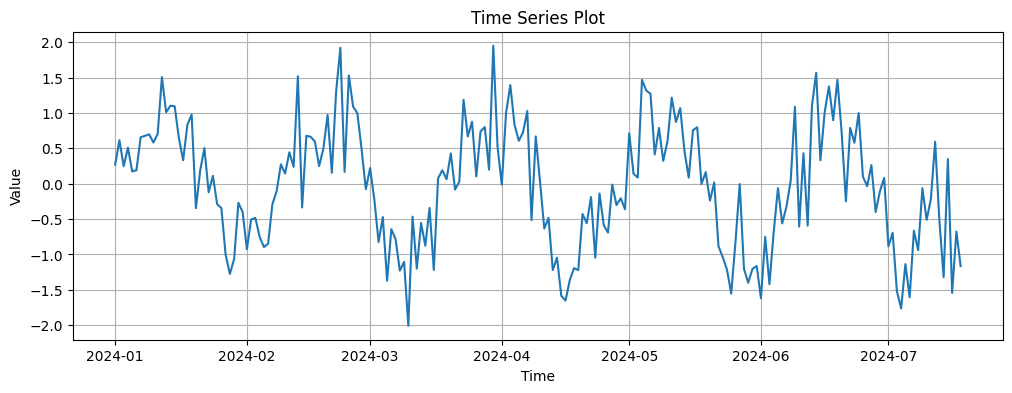

In [9]:
# Create a sample time series (replace with your own data)
dates = pd.date_range('2024-01-01', periods=200, freq='D')
data = np.sin(np.linspace(0, 10 * np.pi, 200)) + np.random.randn(200) * 0.5
ts = pd.Series(data, index=dates)
# Create the time plot
plt.figure(figsize=(12, 4))  # Adjust figure size for better readability
plt.plot(ts)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot")
plt.grid(True)
plt.show()


#### Seaborn can be used to enhance the visual style of time series plots

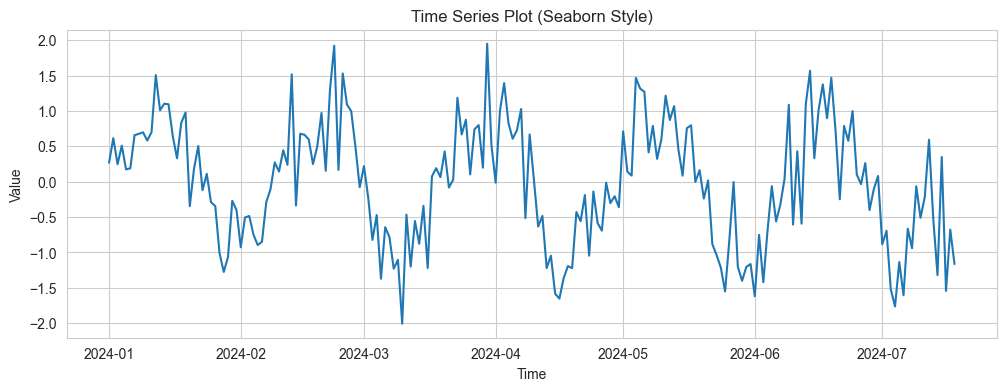

In [10]:
# Set the Seaborn style
sns.set_style("whitegrid")
# Create the time plot (code remains the same as before)
plt.figure(figsize=(12, 4))
plt.plot(ts)
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Time Series Plot (Seaborn Style)")
plt.show()


#### The statsmodels library provides functions for plotting the ACF and PACF, as shown in the following code 

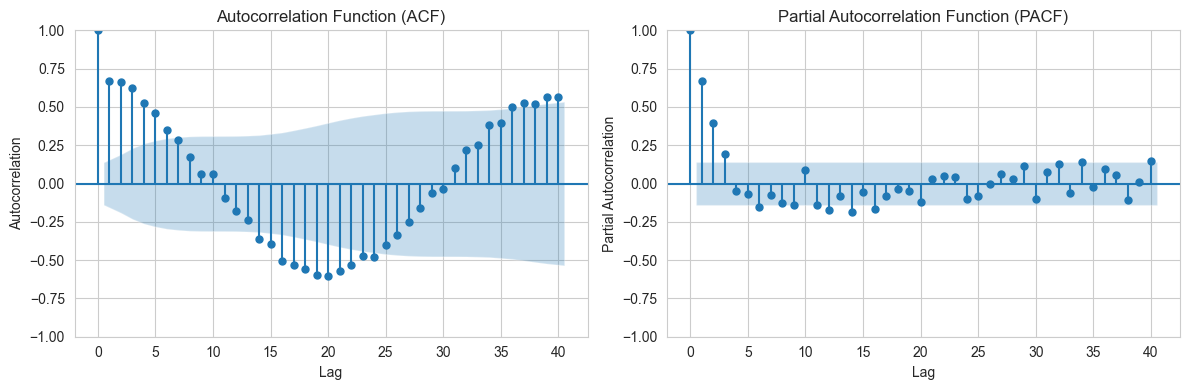

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACF
plot_acf(ts, lags=40, ax=axes[0])
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("Autocorrelation Function (ACF)")

# PACF
plot_pacf(ts, lags=40, ax=axes[1], method='ywm')   # recommended for PACF stability
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Partial Autocorrelation")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

#### The seasonal_decompose function in statsmodels can be used to decompose a time series into its components

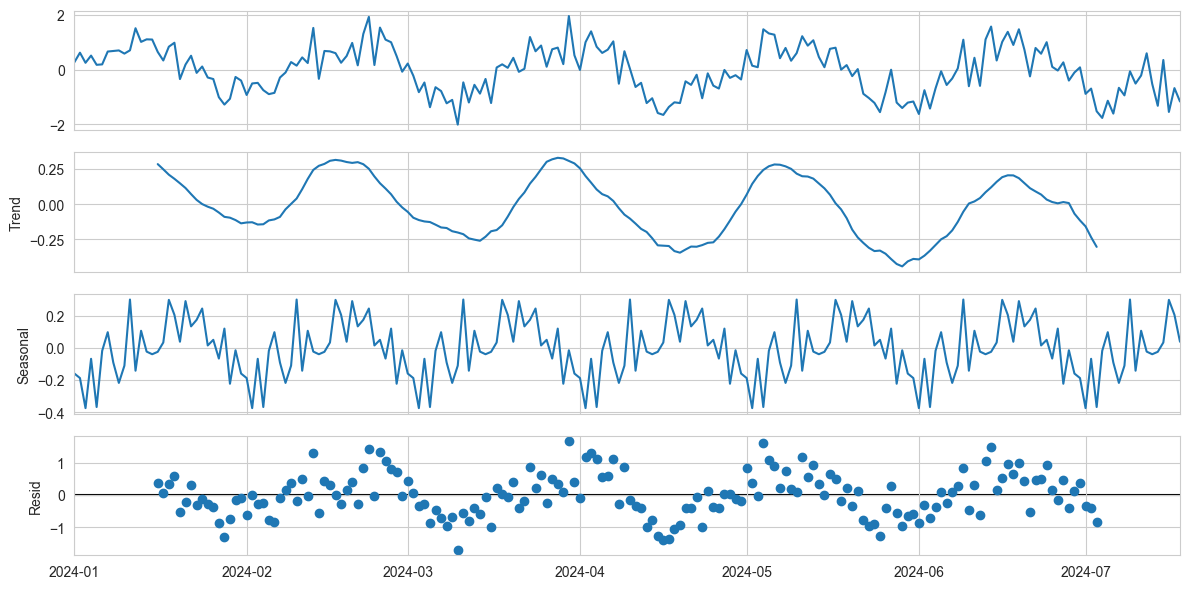

In [12]:
# Perform seasonal decomposition (using additive model as an example)
result = seasonal_decompose(ts, model='additive', period=30)  # Assuming monthly seasonality
# Plot the decomposed components
fig = result.plot()
fig.set_size_inches((12, 6))
plt.tight_layout()
plt.show()

#### A lag plot can be generated using the lag_plot function from pandas.plotting

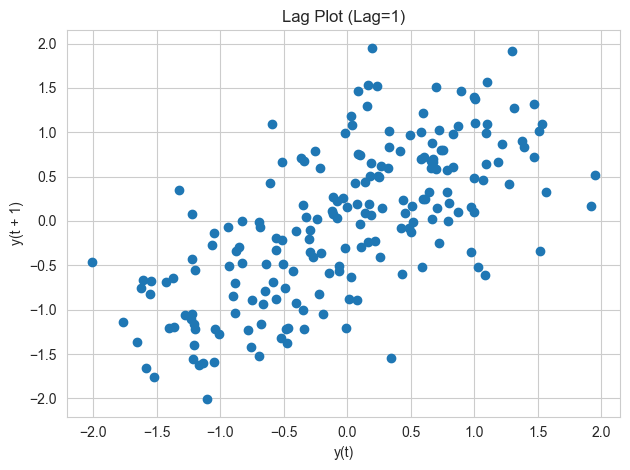

In [13]:
lag_plot(ts, lag=1)
fig.set_size_inches((4, 4))
plt.title("Lag Plot (Lag=1)")
plt.tight_layout()
plt.show()

#### The correlation matrix can be visualized as a heatmap

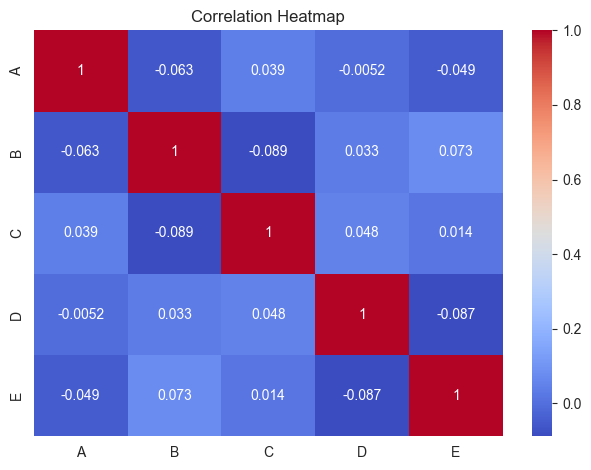

In [14]:
# Example: Heatmap of correlation matrix for multiple time series
data = pd.DataFrame(np.random.randn(200, 5), index=dates, columns=list('ABCDE'))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
fig.set_size_inches((4, 4))
plt.tight_layout()
plt.show()